In [19]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import re

# Projektet skal indeholde
### Fra opgavebeskrivelsen
- An explanation of the central idea behind your project (what is the idea?, why is it interesting? which datasets did you need to explore the idea?, how did you download them)
- An outline on the elements you'll need to get to your goal & the implementation plan.
- A walk-through of your preliminary data-analysis, addressing
- What is the total size of your data? (MB, number of rows, number of variables, etc)
- What is the network you will be analyzing? (number of nodes? number of links?, degree distributions, what are node attributes?, etc.)
- What is the text you will be analyzing?
- How will you tie the two together?

### Vores ideer
- Er der nogle communities?
- Hvem er de mest aktive

# Fetching the data and collecting in one dataframe

In [10]:
# Reading the dataframes
df_agri = pd.read_csv("df_agri.csv")
df_energy = pd.read_csv("df_energy.csv")
df_enterprise = pd.read_csv("df_enterprise.csv")
df_environmental = pd.read_csv("df_environmental.csv")
df_fish = pd.read_csv("df_fish.csv")
df_industrial = pd.read_csv("df_industrial.csv")
df_info = pd.read_csv("df_info.csv")
df_research = pd.read_csv("df_research.csv")
df_transport = pd.read_csv("df_transport.csv")

In [11]:
#Concat all dataframes into one
df = pd.concat([df_agri, df_energy, df_enterprise, df_environmental, df_fish, df_industrial, df_info,
                df_research, df_transport], ignore_index=True)
df

,document_id,title,rapporteurs,shadow_rapporteurs,summary_link
0,2024/0027(COD),Granting equivalence with EU requirements to M...,VRECIONOVÁ Veronika (ECR),"BUDA Daniel (EPP), CÂRCIU Gheorghe (S&D), PENN...",https://oeil.secure.europarl.europa.eu/oeil/en...
1,2023/0448(COD),Protection of animals during transport and rel...,"BUDA Daniel (EPP), METZ Tilly (Greens/EFA)","GIMÉNEZ LARRAZ Borja (EPP), VIND Marianne (S&D...",https://oeil.secure.europarl.europa.eu/oeil/en...
2,2023/0447(COD),Welfare of dogs and cats and their traceability,VRECIONOVÁ Veronika (ECR),"DE MEO Salvatore (EPP), NARDELLA Dario (S&D), ...",https://oeil.secure.europarl.europa.eu/oeil/en...
3,2023/0413(COD),Monitoring framework for resilient European fo...,"SARGIACOMO Eric (S&D), WIESNER Emma (Renew)","KÖHLER Stefan (EPP), BERNHUBER Alexander (EPP)...",https://oeil.secure.europarl.europa.eu/oeil/en...
4,2023/0410(COD),Standing Forest and Forestry Expert Group,"TOVERI Pekka (EPP), WIESNER Emma (Renew)","BERNHUBER Alexander (EPP), TEMIDO Marta (S&D),...",https://oeil.secure.europarl.europa.eu/oeil/en...
...,...,...,...,...,...
680,2020/2115(INI),Connectivity and EU-Asia relations,BÜTIKOFER Reinhard (Greens/EFA),"DELI Andor (EPP), OLEKAS Juozas (S&D), DZHAMBA...",NaN
681,2019/2205(INI),Implementation report on the road safety aspec...,LUTGEN Benoît (EPP),"UJHELYI István (S&D), GHEORGHE Vlad (Renew), M...",NaN
682,2019/2193(INI),Technical and operational measures for more ef...,DELLI Karima (Greens/EFA),"ADAMOWICZ Magdalena (EPP), TAX Vera (S&D), NAG...",NaN
683,2019/2192(INI),Revision of the Trans-European Transport Netwo...,GIESEKE Jens (EPP),"GARCÍA MUÑOZ Isabel (S&D), RIQUET Dominique (R...",NaN


# Network

In [12]:
G = nx.Graph()

# Helper function to clean and split names
def split_names(name_str):
    if pd.isna(name_str):
        return []
    return [name.strip() for name in name_str.split(",")]

def create_network(df):
    for _, row in df.iterrows():
        rapporteurs = split_names(row["rapporteurs"])
        shadow_rapporteurs = split_names(row["shadow_rapporteurs"])

        participants = rapporteurs + shadow_rapporteurs

        for person in participants:
            if not G.has_node(person):
                G.add_node(person)

        # Add edges between all pairs of participants (can restrict to only cross-link rapporteur–shadow if needed)
        for i, p1 in enumerate(participants):
            for p2 in participants[i+1:]:
                if G.has_edge(p1, p2):
                    G[p1][p2]['weight'] += 1
                else:
                    G.add_edge(p1, p2, weight=1)
    return G

G =create_network(df)
G_agri = create_network(df_agri)
G_energy = create_network(df_energy)
G_enterprise = create_network(df_enterprise)
G_environmental = create_network(df_environmental)
G_fish = create_network(df_fish)
G_industrial = create_network(df_industrial)
G_info = create_network(df_info)
G_research = create_network(df_research)
G_transport = create_network(df_transport)

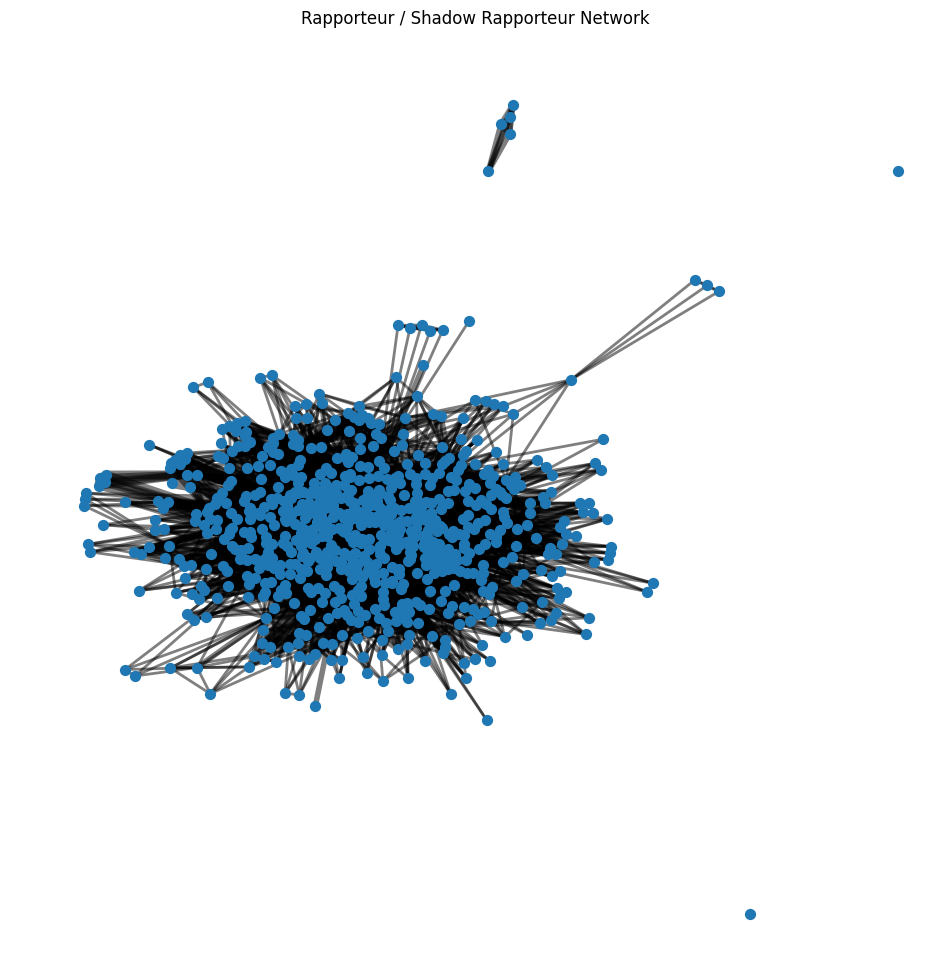

In [17]:
def plot_network(Graph):
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(Graph, k=0.15)
    weights = [Graph[u][v]['weight'] for u,v in Graph.edges()]
    nx.draw_networkx_nodes(Graph, pos, node_size=50)
    nx.draw_networkx_edges(Graph, pos, width=weights, alpha=0.5)
    plt.title("Rapporteur / Shadow Rapporteur Network")
    plt.axis('off')
    plt.show()

plot_network(G)

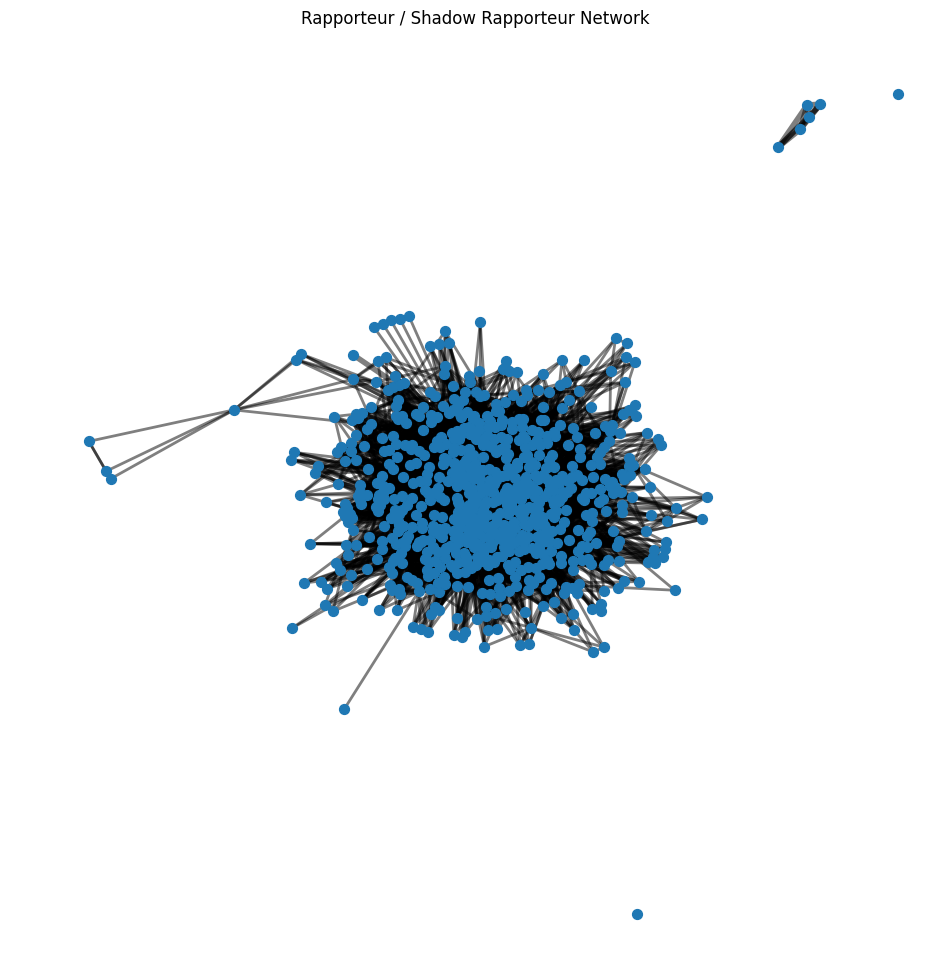

In [18]:
plot_network(G_info)

## Trying to color based on political party
NOTE: det her kommer direkte fra Chat, ville bare prøve og se om det ville give et bedre plot

In [20]:
def split_people(cell):
    if pd.isna(cell):
        return []
    return [p.strip() for p in cell.split(",")]

df['rapporteur_list'] = df['rapporteurs'].apply(split_people)
df['shadow_list'] = df['shadow_rapporteurs'].apply(split_people)

In [21]:
def get_party(person):
    match = re.search(r'\((.*?)\)', person)
    return match.group(1).strip() if match else "Unknown"

In [22]:
all_people = set([person for sublist in df['rapporteur_list'].tolist() + df['shadow_list'].tolist() for person in sublist])
party_lookup = {person: get_party(person) for person in all_people}

In [23]:
G = nx.Graph()

for _, row in df.iterrows():
    rapporteurs = row['rapporteur_list']
    shadows = row['shadow_list']
    
    participants = rapporteurs + shadows
    for person in participants:
        if not G.has_node(person):
            G.add_node(person, party=party_lookup.get(person, "Unknown"))
    
    for i in range(len(participants)):
        for j in range(i + 1, len(participants)):
            p1, p2 = participants[i], participants[j]
            if G.has_edge(p1, p2):
                G[p1][p2]['weight'] += 1
            else:
                G.add_edge(p1, p2, weight=1)

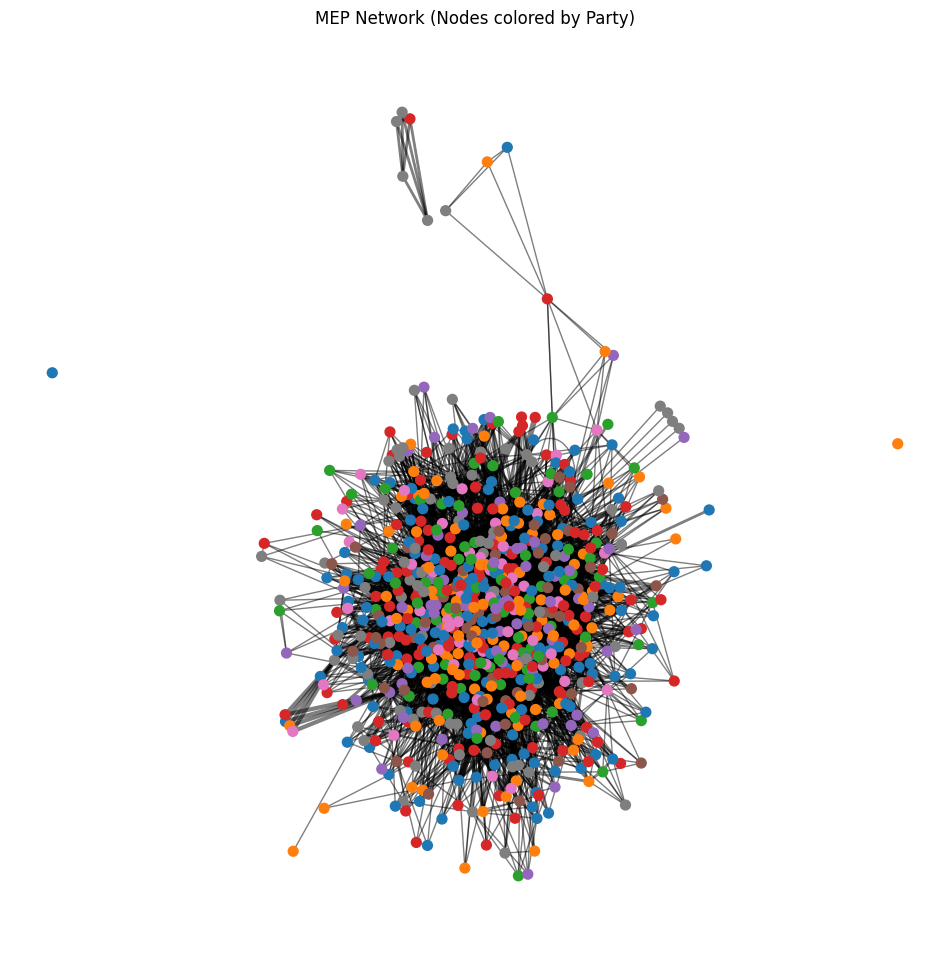

In [24]:
party_colors = {
    "EPP": "#1f77b4", "S&D": "#d62728", "Greens/EFA": "#2ca02c",
    "Renew": "#ff7f0e", "ECR": "#9467bd", "ID": "#8c564b",
    "The Left": "#e377c2", "Unknown": "#7f7f7f"
}

node_colors = [party_colors.get(G.nodes[n]['party'], "#7f7f7f") for n in G.nodes]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.15)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50)
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u,v in G.edges()], alpha=0.5)
plt.title("MEP Network (Nodes colored by Party)")
plt.axis("off")
plt.show()